# ⏱️ Early Stopping — Full Showcase
**TensorFlow + PyTorch**

Demonstrates:
- **Naive** — fixed epoch count (over-fits)
- **EarlyStopping (patience=5)** — stops when val doesn't improve
- **EarlyStopping + restore_best_weights** — goes back to the best checkpoint
- **LR ReduceOnPlateau** — drops LR before stopping
- **Cosine Annealing + warm restarts** (PyTorch only)
- Side-by-side comparison plots + stopped epoch markers

## 1 — Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt, time, copy

import tensorflow as tf
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

print('TF:', tf.__version__, '  PT:', torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

np.random.seed(42); tf.random.set_seed(42); torch.manual_seed(42)

EPOCHS  = 80    # long training so early-stopping has room to act
BATCH   = 128
N_TRAIN = 8_000  # keep small to make over-fitting visible quickly

TF: 2.19.0   PT: 2.10.0+cu128
Device: cuda


In [2]:
# ── data ─────────────────────────────────────────────────────────────────────
(x_all, y_all), (x_val, y_val) = tf.keras.datasets.cifar10.load_data()
x_train = x_all[:N_TRAIN].astype('float32') / 255.
y_train = y_all[:N_TRAIN]
x_val   = x_val.astype('float32') / 255.

AUTOTUNE = tf.data.AUTOTUNE
def make_ds_tf(x, y, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle: ds = ds.shuffle(len(x), seed=42)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

ds_train = make_ds_tf(x_train, y_train)
ds_val   = make_ds_tf(x_val,   y_val, shuffle=False)
print('TF data ready')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
TF data ready


In [4]:
from tensorflow.keras import layers

def build_tf_cnn():
    """Intentionally slightly over-parameterised to show over-fitting."""
    inp = tf.keras.Input((32,32,3))
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    out = layers.Dense(10, activation='softmax')(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def train_tf(callbacks, label):
    tf.random.set_seed(42)
    model = build_tf_cnn()
    t0 = time.time()
    hist = model.fit(ds_train, validation_data=ds_val,
                     epochs=EPOCHS, verbose=0, callbacks=callbacks)
    actual_epochs = len(hist.history['val_accuracy'])
    best_val      = max(hist.history['val_accuracy'])
    print(f'[{label}] stopped at ep {actual_epochs}  '
          f'best_val={best_val:.4f}  ({time.time()-t0:.0f}s)')
    return hist, actual_epochs

In [5]:
# ── A: Naive (no stopping) ────────────────────────────────────────────────────
hist_naive, ep_naive = train_tf([], 'Naive')

[Naive] stopped at ep 80  best_val=0.6403  (121s)


In [6]:
# ── B: EarlyStopping (patience=5) ─────────────────────────────────────────────
cb_es = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, verbose=1)
hist_es, ep_es = train_tf([cb_es], 'EarlyStopping p=5')

Epoch 13: early stopping
[EarlyStopping p=5] stopped at ep 13  best_val=0.6186  (23s)


In [7]:
# ── C: EarlyStopping + restore_best_weights ───────────────────────────────────
cb_es_best = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8,
    restore_best_weights=True, verbose=1)
hist_es_best, ep_es_best = train_tf([cb_es_best], 'ES + restore_best')

Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 17.
[ES + restore_best] stopped at ep 25  best_val=0.6298  (42s)


In [8]:
# ── D: ReduceLROnPlateau + EarlyStopping ──────────────────────────────────────
cb_rlr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
cb_es2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=12,
    restore_best_weights=True, verbose=1)
hist_rlr, ep_rlr = train_tf([cb_rlr, cb_es2], 'ReduceLR + ES')


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 14.
[ReduceLR + ES] stopped at ep 26  best_val=0.6383  (42s)


In [9]:
# ── E: ModelCheckpoint (save best) + EarlyStopping ───────────────────────────
cb_ckpt = tf.keras.callbacks.ModelCheckpoint(
    '/tmp/best_model.keras', monitor='val_accuracy',
    save_best_only=True, verbose=0)
cb_es3  = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8,
    restore_best_weights=True, verbose=1)
hist_ckpt, ep_ckpt = train_tf([cb_ckpt, cb_es3], 'Checkpoint + ES')

# load best saved model
best_model = tf.keras.models.load_model('/tmp/best_model.keras')
_, final_val = best_model.evaluate(ds_val, verbose=0)
print(f'Restored checkpoint val_acc = {final_val:.4f}')

Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 16.
[Checkpoint + ES] stopped at ep 24  best_val=0.6423  (44s)
Restored checkpoint val_acc = 0.6423


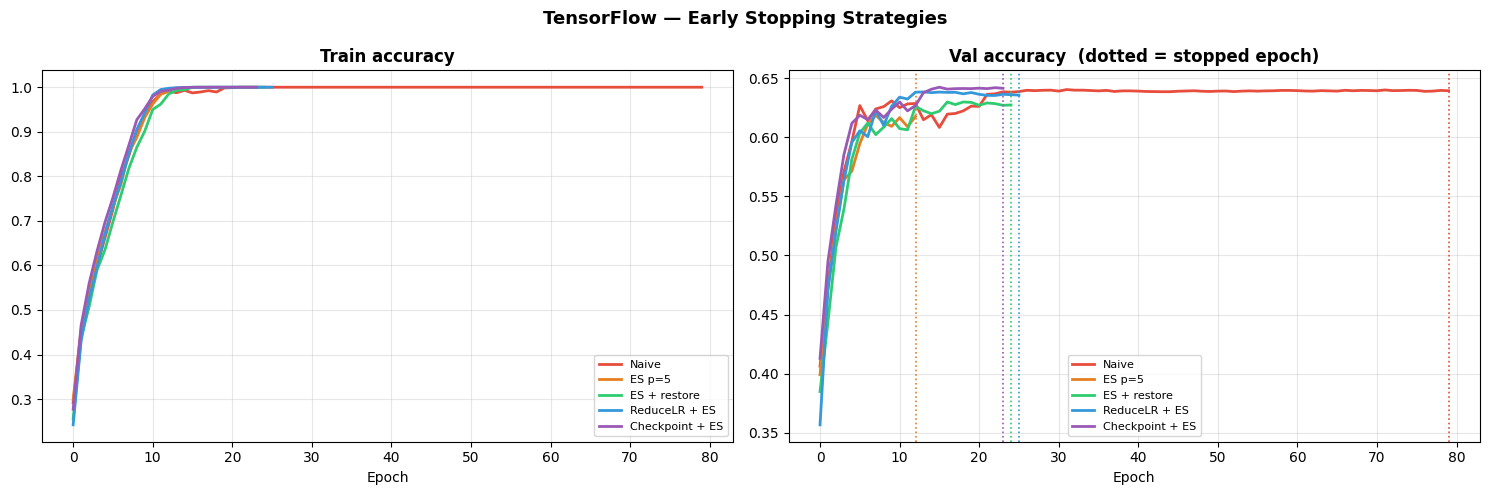


📊 TF Early Stopping Summary
Strategy                   Stopped   BestVal
---------------------------------------------
Naive                      ep  80    0.6403
ES p=5                     ep  13    0.6186
ES + restore               ep  25    0.6298
ReduceLR + ES              ep  26    0.6383
Checkpoint + ES            ep  24    0.6423


In [10]:
# ── TF early stopping comparison plot ────────────────────────────────────────
experiments_tf = [
    ('Naive',           hist_naive,   ep_naive,   '#e74c3c'),
    ('ES p=5',          hist_es,      ep_es,      '#e67e22'),
    ('ES + restore',    hist_es_best, ep_es_best, '#2ecc71'),
    ('ReduceLR + ES',   hist_rlr,     ep_rlr,     '#3498db'),
    ('Checkpoint + ES', hist_ckpt,    ep_ckpt,    '#9b59b6'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for label, hist, ep, color in experiments_tf:
    tr = hist.history['accuracy']
    va = hist.history['val_accuracy']
    axes[0].plot(tr, color=color, label=label, lw=2)
    axes[1].plot(va, color=color, label=label, lw=2)
    axes[1].axvline(ep-1, color=color, ls=':', lw=1.2)

axes[0].set_title('Train accuracy', fontweight='bold')
axes[1].set_title('Val accuracy  (dotted = stopped epoch)', fontweight='bold')
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_xlabel('Epoch')

plt.suptitle('TensorFlow — Early Stopping Strategies', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📊 TF Early Stopping Summary')
print(f'{"Strategy":25s}  {"Stopped":>7}  {"BestVal":>8}')
print('-' * 45)
for lbl, hist, ep, _ in experiments_tf:
    print(f'{lbl:25s}  ep {ep:3d}    {max(hist.history["val_accuracy"]):.4f}')

## 3 — PyTorch Early Stopping

In [11]:
# ── data ─────────────────────────────────────────────────────────────────────
mean_pt, std_pt = (0.4914,0.4822,0.4465), (0.2023,0.1994,0.2010)
tf_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean_pt, std_pt)])

root = '/tmp/cifar'
full_tr = datasets.CIFAR10(root, train=True,  download=True,  transform=tf_norm)
val_set = datasets.CIFAR10(root, train=False, download=False, transform=tf_norm)
small_tr = Subset(full_tr, list(range(N_TRAIN)))

loader_tr = DataLoader(small_tr, batch_size=BATCH, shuffle=True,  num_workers=2)
loader_va = DataLoader(val_set,  batch_size=256,   shuffle=False, num_workers=2)
print('PT data ready')

100%|██████████| 170M/170M [00:05<00:00, 28.5MB/s]


PT data ready


In [12]:
# ── shared CNN ───────────────────────────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128*8*8, 512), nn.ReLU(),
            nn.Linear(512, 10),
        )
    def forward(self, x): return self.net(x)


# ── manual early-stopper class ────────────────────────────────────────────────
class EarlyStopper:
    """Stops training when monitored metric does not improve."""
    def __init__(self, patience=5, min_delta=0., restore_best=True):
        self.patience     = patience
        self.min_delta    = min_delta
        self.restore_best = restore_best
        self.best_score   = -np.inf
        self.best_weights = None
        self.wait         = 0
        self.stopped_epoch = None

    def __call__(self, score, model, epoch):
        if score > self.best_score + self.min_delta:
            self.best_score   = score
            self.wait         = 0
            if self.restore_best:
                self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                if self.restore_best and self.best_weights:
                    model.load_state_dict(self.best_weights)
                    print(f'  Restored best weights (val={self.best_score:.4f})')
                return True   # stop
        return False


# ── training loop factory ─────────────────────────────────────────────────────
def run_pt(name, scheduler_fn=None, early_stopper=None):
    torch.manual_seed(42)
    model = CNN().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = scheduler_fn(opt) if scheduler_fn else None
    crit  = nn.CrossEntropyLoss()
    tr_accs, va_accs = [], []
    stopped_ep = EPOCHS
    print(f'\n→ Training {name}')
    for ep in range(1, EPOCHS+1):
        # train
        model.train(); correct, total = 0, 0
        for x, y in loader_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss = crit(model(x), y); loss.backward(); opt.step()
            with torch.no_grad():
                correct += (model(x).argmax(1)==y).sum().item(); total += y.size(0)
        tr_accs.append(correct/total)
        # validate
        model.eval(); vc, vt = 0, 0
        with torch.no_grad():
            for x, y in loader_va:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vc += (model(x).argmax(1)==y).sum().item(); vt += y.size(0)
        va = vc/vt; va_accs.append(va)
        # scheduler step
        if sched is not None:
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(va)
            else:
                sched.step()
        if ep % 20 == 0: print(f'  ep {ep:2d}  val={va:.4f}')
        # early stopping
        if early_stopper is not None:
            if early_stopper(va, model, ep):
                stopped_ep = ep
                print(f'  [Early stop] at epoch {ep}')
                break
    print(f'  best val = {max(va_accs):.4f}')
    return tr_accs, va_accs, stopped_ep

In [13]:
# ── A: Naive ──────────────────────────────────────────────────────────────────
r_naive = run_pt('Naive (no stopping)')


→ Training Naive (no stopping)
  ep 20  val=0.6099
  ep 40  val=0.6237
  ep 60  val=0.6261
  ep 80  val=0.6275
  best val = 0.6276


In [14]:
# ── B: EarlyStopping patience=5 ───────────────────────────────────────────────
r_es5 = run_pt('ES patience=5',
               early_stopper=EarlyStopper(patience=5, restore_best=False))


→ Training ES patience=5
  [Early stop] at epoch 14
  best val = 0.6205


In [15]:
# ── C: EarlyStopping + restore best ───────────────────────────────────────────
r_es_best = run_pt('ES + restore best',
                   early_stopper=EarlyStopper(patience=8, restore_best=True))


→ Training ES + restore best
  Restored best weights (val=0.6218)
  [Early stop] at epoch 18
  best val = 0.6218


In [17]:
# ── D: ReduceLROnPlateau + EarlyStopping ──────────────────────────────────────
r_rlr = run_pt(
    'ReduceLR + ES',
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=4),
    early_stopper=EarlyStopper(patience=12, restore_best=True))


→ Training ReduceLR + ES
  ep 20  val=0.6262
  ep 40  val=0.6343
  Restored best weights (val=0.6344)
  [Early stop] at epoch 53
  best val = 0.6344


In [18]:
# ── E: Cosine Annealing with warm restarts (SGDR) ─────────────────────────────
r_cos = run_pt(
    'CosineAnnealing WarmRestarts',
    scheduler_fn=lambda opt: torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=10, T_mult=2),
    early_stopper=EarlyStopper(patience=15, restore_best=True))


→ Training CosineAnnealing WarmRestarts
  ep 20  val=0.6336
  Restored best weights (val=0.6346)
  [Early stop] at epoch 38
  best val = 0.6346


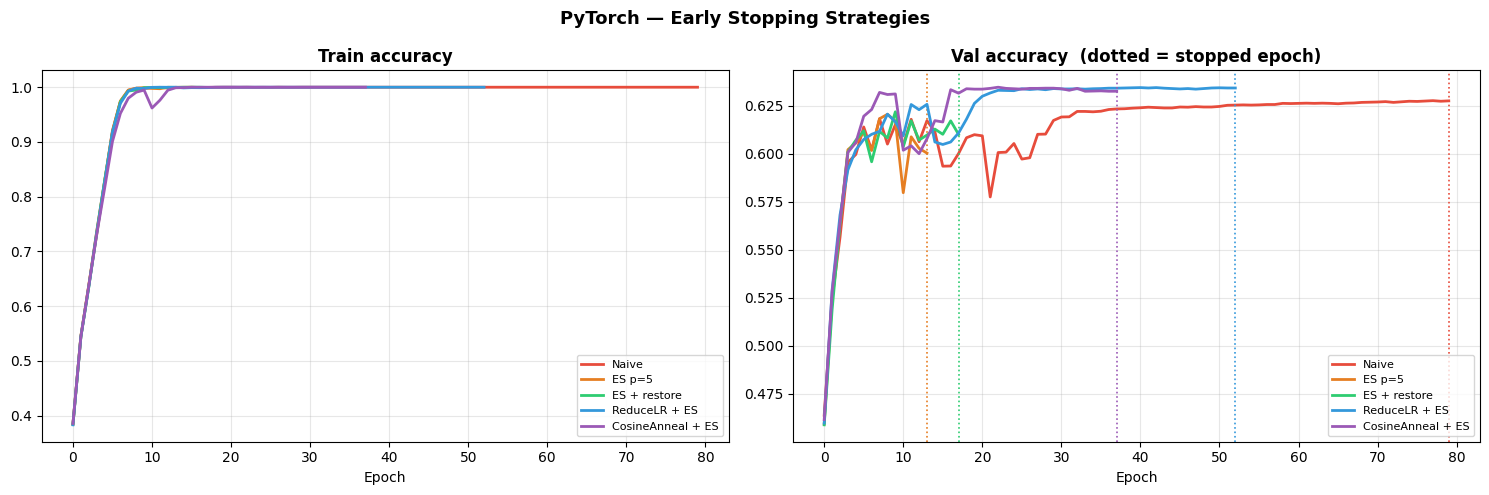


📊 PT Early Stopping Summary
Strategy                     Stopped   BestVal
------------------------------------------------
Naive                        ep  80    0.6276
ES p=5                       ep  14    0.6205
ES + restore                 ep  18    0.6218
ReduceLR + ES                ep  53    0.6344
CosineAnneal + ES            ep  38    0.6346


In [19]:
# ── PyTorch comparison plot ────────────────────────────────────────────────────
experiments_pt = [
    ('Naive',               r_naive,   '#e74c3c'),
    ('ES p=5',              r_es5,     '#e67e22'),
    ('ES + restore',        r_es_best, '#2ecc71'),
    ('ReduceLR + ES',       r_rlr,     '#3498db'),
    ('CosineAnneal + ES',   r_cos,     '#9b59b6'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for label, (tr, va, ep), color in experiments_pt:
    axes[0].plot(tr, color=color, label=label, lw=2)
    axes[1].plot(va, color=color, label=label, lw=2)
    axes[1].axvline(ep-1, color=color, ls=':', lw=1.2)

axes[0].set_title('Train accuracy', fontweight='bold')
axes[1].set_title('Val accuracy  (dotted = stopped epoch)', fontweight='bold')
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_xlabel('Epoch')

plt.suptitle('PyTorch — Early Stopping Strategies', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n📊 PT Early Stopping Summary')
print(f'{"Strategy":27s}  {"Stopped":>7}  {"BestVal":>8}')
print('-' * 48)
for lbl, (tr, va, ep), _ in experiments_pt:
    print(f'{lbl:27s}  ep {ep:3d}    {max(va):.4f}')

## 4 — Patience sensitivity analysis


Patience = 2

→ Training ES p=2
  Restored best weights (val=0.6218)
  [Early stop] at epoch 10
  best val = 0.6218

Patience = 5

→ Training ES p=5
  Restored best weights (val=0.6163)
  [Early stop] at epoch 13
  best val = 0.6163

Patience = 10

→ Training ES p=10
  Restored best weights (val=0.6177)
  [Early stop] at epoch 18
  best val = 0.6177

Patience = 20

→ Training ES p=20
  ep 20  val=0.6206
  ep 40  val=0.6274
  Restored best weights (val=0.6317)
  [Early stop] at epoch 44
  best val = 0.6317


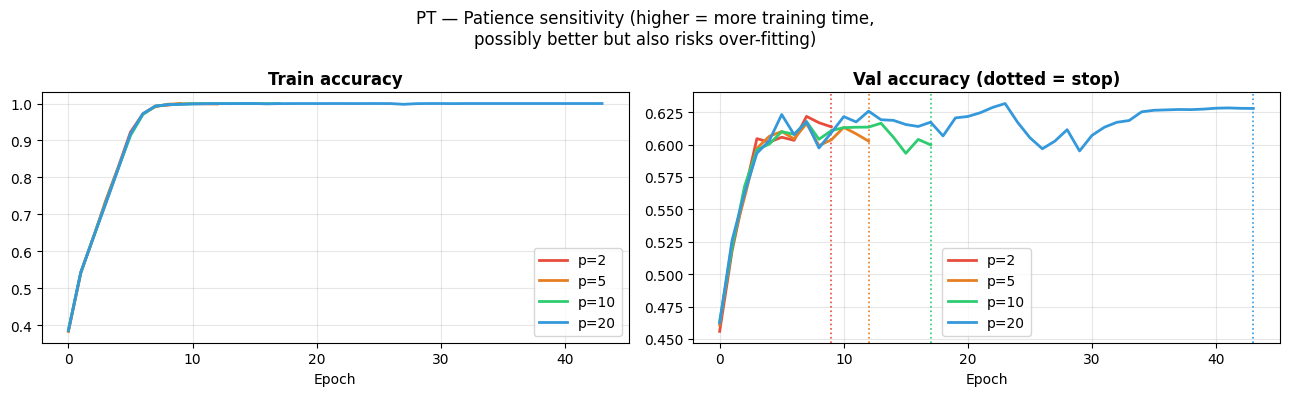


Patience  Stopped  BestVal
  p= 2    ep  10    0.6218
  p= 5    ep  13    0.6163
  p=10    ep  18    0.6177
  p=20    ep  44    0.6317


In [20]:
# How does patience affect the stopped epoch and best val acc?
patience_vals = [2, 5, 10, 20]
p_results = {}
for p in patience_vals:
    print(f'\nPatience = {p}')
    p_results[p] = run_pt(f'ES p={p}',
                          early_stopper=EarlyStopper(patience=p, restore_best=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#e74c3c','#e67e22','#2ecc71','#3498db']
for (p, (tr, va, ep)), c in zip(p_results.items(), colors):
    axes[0].plot(tr, color=c, label=f'p={p}', lw=2)
    axes[1].plot(va, color=c, label=f'p={p}', lw=2)
    axes[1].axvline(ep-1, color=c, ls=':', lw=1.2)

axes[0].set_title('Train accuracy', fontweight='bold')
axes[1].set_title('Val accuracy (dotted = stop)', fontweight='bold')
for ax in axes:
    ax.legend(); ax.grid(alpha=.3); ax.set_xlabel('Epoch')

plt.suptitle('PT — Patience sensitivity (higher = more training time,\n'
             'possibly better but also risks over-fitting)', fontsize=12)
plt.tight_layout(); plt.show()

print('\nPatience  Stopped  BestVal')
for p, (_, va, ep) in p_results.items():
    print(f'  p={p:2d}    ep {ep:3d}    {max(va):.4f}')

## 5 — Learning Rate curve (ReduceLROnPlateau vs CosineAnnealing)

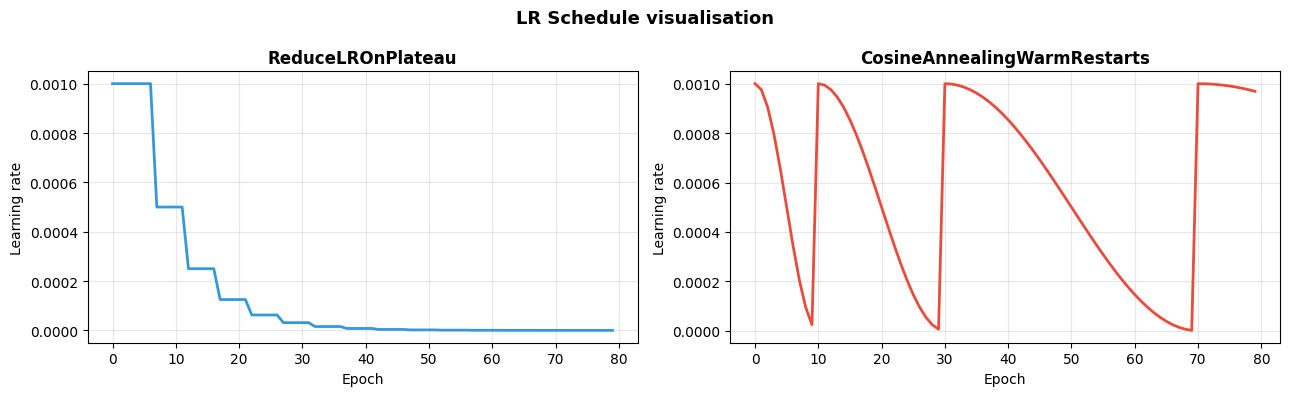

In [21]:
# Visualise LR schedule without full training
def simulate_lr(scheduler_fn, n_steps=80, plateau_every=15):
    """Simulate LR by feeding fake plateau signals."""
    dummy_opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=1e-3)
    sched = scheduler_fn(dummy_opt)
    lrs = []
    for i in range(n_steps):
        lrs.append(dummy_opt.param_groups[0]['lr'])
        if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
            val_metric = 0.9 if i % plateau_every != 0 else 0.5
            sched.step(val_metric)
        else:
            sched.step()
    return lrs

lrs_rlr = simulate_lr(lambda o: torch.optim.lr_scheduler.ReduceLROnPlateau(
    o, mode='max', factor=0.5, patience=4))
lrs_cos = simulate_lr(lambda o: torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    o, T_0=10, T_mult=2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lrs_rlr, color='#3498db', lw=2)
axes[0].set_title('ReduceLROnPlateau', fontweight='bold')
axes[1].plot(lrs_cos, color='#e74c3c', lw=2)
axes[1].set_title('CosineAnnealingWarmRestarts', fontweight='bold')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate'); ax.grid(alpha=.3)
plt.suptitle('LR Schedule visualisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()